### SE HACE LO MISMO QUE EN EL _02_Red_Neuronal_Principal.py, pero añadiendo gráficos

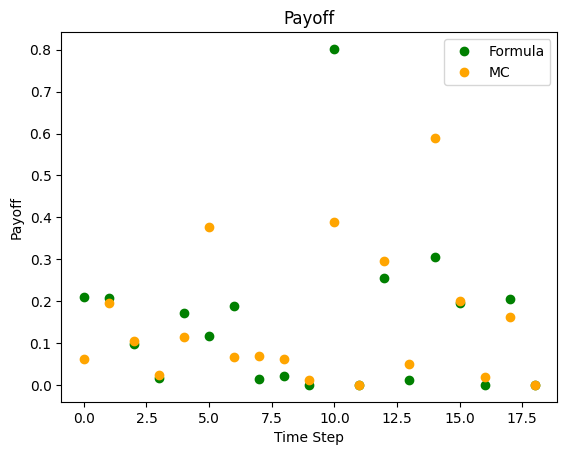

Firma detectada de MonteCarlo: (initial_maturity, S_0, num_sims, num_assets, num_asian_dates, value_date_index, correl_matrix, risk_free_rate, vols)
Generadas 10000/100000 filas...
Generadas 20000/100000 filas...
Generadas 30000/100000 filas...
Generadas 40000/100000 filas...
Generadas 50000/100000 filas...
Generadas 60000/100000 filas...
Generadas 70000/100000 filas...
Generadas 80000/100000 filas...
Generadas 90000/100000 filas...
Generadas 100000/100000 filas...
Dataset guardado en: C:\BDATA\RETOS GIT\RETO9_GORKA\25-26_3_R9_EQUIPO_AZUL_CLARO\25-26_3_R9_AZUL_CLARO\Datos\Transformados\synthetic_mc_dataset.csv


In [1]:
"""
Generar 100.000 filas sintéticas desde Cartera_Close.csv con la función MonteCarlo
del notebook 'MonteCarlo_y_Formula_cerrada_25_26.ipynb', creando 'synthetic_mc_dataset.csv'.

Soluciona:
- Errores de broadcasting (pasa S_0 como (3,1) y reintenta combinaciones seguras con vols).
- MonteCarlo que no devuelve un escalar: extractor de precio 'auto' (o configurable).

Salida: CSV con secuencia 20x3 (normalizada por S0), estáticos (r, sigmas, corr, S0, K, T) y 'price_mc'.
"""

import json, math
import numpy as np
import pandas as pd
from pathlib import Path
import inspect, types
from typing import Dict, Any, List, Tuple
import torch
import os

path_clean_data = os.path.join('Datos','Transformados')
if not os.path.exists(path_clean_data):
  os.makedirs(path_clean_data)

# ===================== CONFIG =====================
CSV_PATH   = Path("Datos/Limpios/Cartera_Close.csv")                 
IPYNB_PATH = Path("MonteCarlo_y_Formula_cerrada_25_26.ipynb")

N_ROWS            = 100_000
WINDOW_LEN        = 20
LOOKBACK          = 252
T_YEARS           = 5.0
N_STEPS           = 20
VALUE_DATE_INDEX  = 0
NUM_ASSETS        = 3
MC_SIMS_PER_ROW   = 2_000
CHUNK_SAVE        = 10_000
OUT_CSV           = Path("Datos/Transformados/synthetic_mc_dataset.csv")
SEED              = 123

# === EXTRACTOR de precio (si 'auto' no acierta, indica cómo sacar el escalar) ===
EXTRACT_MODE       = "auto"     # "auto" | "tuple_index" | "dict_key" | "array_last"
FORCE_TUPLE_INDEX  = 0          # si EXTRACT_MODE="tuple_index", usa este índice
FORCE_DICT_KEY     = "price"    # si EXTRACT_MODE="dict_key", usa esta clave
ARRAY_TAKE         = "last"     # si EXTRACT_MODE="array_last": "last" | "mean" | "first"

# ==================================================


# =============== UTILIDADES DE TIPO/SHAPE ===============
def as_int(x) -> int:
    return int(np.asarray(x).reshape(()).item())

def as_f1(x) -> np.ndarray:
    v = np.asarray(x, dtype=np.float64).reshape(-1)
    return np.ascontiguousarray(v)

def as_f2(x) -> np.ndarray:
    M = np.asarray(x, dtype=np.float64)
    if M.ndim == 1:
        n = int(round(math.sqrt(M.size)))
        M = M.reshape(n, n)
    return np.ascontiguousarray(M)


# =============== EXTRACTOR DE PRECIO ===============
def extract_price_scalar(out) -> float:
    """
    Intenta obtener un float de 'out' con varias estrategias.
    Si EXTRACT_MODE != 'auto', usa el modo indicado arriba.
    """
    import numbers
    # Modo directo
    if isinstance(out, numbers.Number):
        return float(out)

    if EXTRACT_MODE == "tuple_index":
        assert isinstance(out, (tuple, list)), "Se indicó 'tuple_index' pero la salida no es tuple/list."
        return extract_price_scalar(out[FORCE_TUPLE_INDEX])

    if EXTRACT_MODE == "dict_key":
        assert isinstance(out, dict), "Se indicó 'dict_key' pero la salida no es dict."
        assert FORCE_DICT_KEY in out, f"Clave '{FORCE_DICT_KEY}' no está en la salida del dict."
        return extract_price_scalar(out[FORCE_DICT_KEY])

    if EXTRACT_MODE == "array_last":
        arr = np.asarray(out)
        if arr.ndim == 0:
            return float(arr)
        if arr.size == 1:
            return float(arr.reshape(-1)[0])
        if ARRAY_TAKE == "last":
            return float(arr.reshape(-1)[-1])
        elif ARRAY_TAKE == "first":
            return float(arr.reshape(-1)[0])
        else:  # mean
            return float(np.nanmean(arr))

    # ---- MODO AUTO ----
    # 1) numpy array
    if isinstance(out, np.ndarray):
        if out.ndim == 0:
            return float(out)
        if out.size == 1:
            return float(out.reshape(-1)[0])
        # array con más de un elemento
        return float(out.reshape(-1)[-1])  # por defecto, último elemento

    # 2) list/tuple: busca el primer escalar o array escalarizable
    if isinstance(out, (list, tuple)):
        for elem in out:
            try:
                return extract_price_scalar(elem)
            except Exception:
                continue
        raise TypeError("No se encontró un escalar interpretable dentro de la salida tuple/list.")

    # 3) dict: busca claves habituales
    if isinstance(out, dict):
        for key in ("price","premium","value","payoff","Price","Premium","Value","Payoff"):
            if key in out:
                return extract_price_scalar(out[key])
        # si no, intenta cualquier valor escalarizable
        for k, v in out.items():
            try:
                return extract_price_scalar(v)
            except Exception:
                continue
        raise TypeError("No se encontró un valor escalar interpretable dentro del dict devuelto por MonteCarlo.")

    # 4) fallback: intenta convertir a float directamente
    try:
        return float(out)
    except Exception as e:
        raise TypeError(f"No se pudo extraer un escalar de la salida de MonteCarlo (tipo {type(out)}). "
                        f"Configura EXTRACT_MODE/clave/índice arriba. Error: {e}")


# =============== IO: CSV & Notebook ===============
def load_close_data(csv_path: Path) -> pd.DataFrame:
    assert csv_path.exists(), f"No existe {csv_path}"
    df = pd.read_csv(csv_path)
    assert {"trading_day","AAPL","MSFT","CAT"}.issubset(df.columns), \
        "El CSV debe contener: trading_day, AAPL, MSFT, CAT"
    df["trading_day"] = pd.to_datetime(df["trading_day"])
    return df.sort_values("trading_day").reset_index(drop=True)

def load_ipynb_namespace(nb_path: Path) -> Dict[str, Any]:
    assert nb_path.exists(), f"No existe {nb_path}"
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)
    ns: Dict[str, Any] = {"__name__":"__notebook__"}
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            src = "".join(cell.get("source", []))
            if src.strip():
                exec(compile(src, filename=str(nb_path), mode="exec"), ns, ns)
    return ns


# =============== ESTADÍSTICAS (252 días) ===============
def compute_log_returns(df: pd.DataFrame) -> np.ndarray:
    px = df[["AAPL","MSFT","CAT"]].values
    return np.log(px[1:]/px[:-1])

def annualized_stats_from_window(lr252: np.ndarray) -> Tuple[float, np.ndarray, np.ndarray]:
    mu_d = lr252.mean(axis=0)
    sig_d = lr252.std(axis=0, ddof=1)
    mu_ann = mu_d * 252.0
    sig_ann = sig_d * math.sqrt(252.0)
    corr = np.corrcoef(lr252.T)
    r_ann = float(mu_ann.mean())
    return r_ann, sig_ann, corr

def forward_strike_3y(S0_vec: np.ndarray, r_ann: float) -> float:
    w = np.ones(3)/3.0
    return float(np.dot(S0_vec, w) * math.exp(r_ann*3.0))


# =============== LLAMADA DINÁMICA A MonteCarlo (con reintentos) ===============
def build_args_in_signature_order(sig: inspect.Signature, values: Dict[str, Any]) -> Tuple:
    args, missing = [], []
    for name in sig.parameters:
        if name in values: args.append(values[name])
        else: missing.append(name)
    if missing:
        raise RuntimeError(f"Faltan argumentos para MonteCarlo: {missing}. "
                           f"Disponibles: {list(values.keys())}")
    return tuple(args)

def _call_mc_once(mc_fn, sig, *, T_years, S0_vec, S0_mat, nsims, nassets, nsteps, val_idx, corr, r, vols_vec, vols_mat):
    values = {
        "initial_maturity": float(T_years), "T": float(T_years),
        "S_0": S0_mat,      # (3,1) para broadcasting con (nsims, 3, steps)
        "S0":  S0_vec,      # por si la firma usara 'S0'
        "num_sims": as_int(nsims), "nsims": as_int(nsims),
        "num_assets": as_int(nassets), "n_assets": as_int(nassets),
        "num_asian_dates": as_int(nsteps), "n_asian_dates": as_int(nsteps), "n_steps": as_int(nsteps),
        "value_date_index": as_int(val_idx), "val_index": as_int(val_idx),
        "correl_matrix": as_f2(corr), "corr": as_f2(corr),
        "risk_free_rate": float(r), "r": float(r),
        "vols":  vols_vec, "sigmas": vols_vec,           # preferimos vector
        "vols_mat": vols_mat, "sigmas_mat": vols_mat,    # por si el cuaderno acepta otra clave
    }
    # args en el ORDEN REAL de la firma
    args = []
    for name in sig.parameters:
        if name in values:
            args.append(values[name])
        else:
            raise RuntimeError(f"Parámetro '{name}' de la firma no está mapeado (ajusta el mapping).")
    out = mc_fn(*tuple(args))
    return extract_price_scalar(out)

def call_montecarlo_by_signature(mc_fn, T_years, S0, nsims, nassets,
                                 nsteps, val_idx, corr, r, vols) -> float:
    sig = inspect.signature(mc_fn)
    S0_vec  = as_f1(S0)                            # (3,)
    S0_mat  = S0_vec.reshape(as_int(nassets), 1)   # (3,1)
    vols_vec= as_f1(vols)                          # (3,)
    vols_mat= vols_vec.reshape(as_int(nassets), 1) # (3,1)
    corr    = as_f2(corr)

    # 1) S_0=(3,1), vols=(3,)
    try:
        return _call_mc_once(mc_fn, sig, T_years=T_years, S0_vec=S0_vec, S0_mat=S0_mat,
                             nsims=nsims, nassets=nassets, nsteps=nsteps, val_idx=val_idx,
                             corr=corr, r=r, vols_vec=vols_vec, vols_mat=vols_mat)
    except ValueError as e:
        if "operands could not be broadcast together" not in str(e):
            raise
    # 2) S_0=(3,1), vols=(3,1)
    try:
        return _call_mc_once(mc_fn, sig, T_years=T_years, S0_vec=S0_vec, S0_mat=S0_mat,
                             nsims=nsims, nassets=nassets, nsteps=nsteps, val_idx=val_idx,
                             corr=corr, r=r, vols_vec=vols_mat, vols_mat=vols_mat)
    except ValueError as e:
        if "operands could not be broadcast together" not in str(e):
            raise
    # 3) S_0=(3,), vols=(3,)
    return _call_mc_once(mc_fn, sig, T_years=T_years, S0_vec=S0_vec, S0_mat=S0_vec,
                         nsims=nsims, nassets=nassets, nsteps=nsteps, val_idx=val_idx,
                         corr=corr, r=r, vols_vec=vols_vec, vols_mat=vols_mat)


# =============== PIPELINE PRINCIPAL ===============
def build_synthetic_dataset(csv_path: Path,
                            ipynb_path: Path,
                            n_rows: int,
                            window_len: int,
                            lookback: int,
                            T_years: float,
                            num_steps: int,
                            value_date_index: int,
                            num_assets: int,
                            mc_sims_per_row: int,
                            out_csv: Path,
                            seed: int) -> None:
    np.random.seed(seed)

    # 1) Datos
    df = load_close_data(csv_path)
    lr_all = compute_log_returns(df)
    px = df[["AAPL","MSFT","CAT"]].values
    N = len(df)
    start = lookback + (window_len - 1)
    valid_t = np.arange(start, N)
    assert len(valid_t) > 0, "Insuficientes filas (lookback=252, ventana=20)."

    # 2) Cargar notebook y obtener MonteCarlo
    ns = load_ipynb_namespace(ipynb_path)
    assert "MonteCarlo" in ns and isinstance(ns["MonteCarlo"], types.FunctionType), \
        "No se encontró 'MonteCarlo' en el notebook."
    MonteCarlo = ns["MonteCarlo"]
    sig = inspect.signature(MonteCarlo)
    print("Firma detectada de MonteCarlo:", sig)

    # 3) Generar dataset y escribir por chunks
    header_written = False
    rows: List[Dict[str, Any]] = []

    for i in range(n_rows):
        t = int(np.random.choice(valid_t))
        win = px[t - (window_len - 1): t + 1, :]              # (20,3)
        S0 = win[-1].astype(np.float64)                       # (3,)
        seq_norm = (win / S0.reshape(1,3)).astype(np.float32) # ↓ memoria en CSV

        lr_win = lr_all[(t-1)-(lookback-1): (t-1)+1, :]       # (252,3)
        r_ann, sig_ann, corr = annualized_stats_from_window(lr_win)
        K = forward_strike_3y(S0, r_ann)

        price_mc = call_montecarlo_by_signature(
            MonteCarlo,
            T_years=T_YEARS, S0=S0,
            nsims=MC_SIMS_PER_ROW, nassets=NUM_ASSETS,
            nsteps=N_STEPS, val_idx=VALUE_DATE_INDEX,
            corr=corr, r=r_ann, vols=sig_ann
        )

        row = {
            "trading_day_end": df.loc[t, "trading_day"],
            "r_ann": float(r_ann),
            "sigma_AAPL": float(sig_ann[0]),
            "sigma_MSFT": float(sig_ann[1]),
            "sigma_CAT":  float(sig_ann[2]),
            "corr_AM": float(corr[0,1]),
            "corr_AC": float(corr[0,2]),
            "corr_MC": float(corr[1,2]),
            "S0_AAPL": float(S0[0]),
            "S0_MSFT": float(S0[1]),
            "S0_CAT":  float(S0[2]),
            "K_forward_3y": float(K),
            "T_years": float(T_YEARS),
            "price_mc": float(price_mc),
        }
        for k in range(window_len):
            row[f"AAPL_t{k}"] = float(seq_norm[k,0])
            row[f"MSFT_t{k}"] = float(seq_norm[k,1])
            row[f"CAT_t{k}"]  = float(seq_norm[k,2])

        rows.append(row)

        # Volcado por chunks
        if (i + 1) % CHUNK_SAVE == 0:
            print(f"Generadas {i+1}/{n_rows} filas...")
            df_chunk = pd.DataFrame(rows)
            df_chunk.to_csv(out_csv, index=False, mode=("a" if header_written else "w"),
                            header=not header_written)
            header_written = True
            rows = []  # libera memoria

    # Guardar lo que falte
    if rows:
        df_chunk = pd.DataFrame(rows)
        df_chunk.to_csv(out_csv, index=False, mode=("a" if header_written else "w"),
                        header=not header_written)

    print(f"Dataset guardado en: {out_csv.resolve()}")


if __name__ == "__main__":
    build_synthetic_dataset(
        csv_path=CSV_PATH,
        ipynb_path=IPYNB_PATH,
        n_rows=N_ROWS,
        window_len=WINDOW_LEN,
        lookback=LOOKBACK,
        T_years=T_YEARS,
        num_steps=N_STEPS,
        value_date_index=VALUE_DATE_INDEX,
        num_assets=NUM_ASSETS,
        mc_sims_per_row=MC_SIMS_PER_ROW,
        out_csv=OUT_CSV,
        seed=SEED
    )


In [2]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.0, save_path="./best_model.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.min_validation_loss = float('inf')
    def early_stop(self, validation_loss, model):
        if validation_loss < self.min_validation_loss - self.min_delta:
            self.min_validation_loss = validation_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
import os, math, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# -------------------- Config --------------------
CSV_PATH = Path("Datos/Transformados/synthetic_mc_dataset.csv")  
assert CSV_PATH.exists(), f"No existe el CSV: {CSV_PATH}"
SEED = 123
torch.manual_seed(SEED); np.random.seed(SEED)

BATCH_SIZE = 512
EPOCHS     = 25          
PATIENCE   = 5
LR         = 1e-3
CLIP_NORM  = 1.0

OUTDIR     = Path("./model_selection_runs")
OUTDIR.mkdir(exist_ok=True, parents=True)

# -------------------- Load & validate --------------------
df = pd.read_csv(str(CSV_PATH), parse_dates=["trading_day_end"])
print("Loaded:", CSV_PATH, "shape:", df.shape, "| NaNs:", int(df.isna().sum().sum()))

# Derive payoff (target) & basic checks
df["payoff"] = (df["price_mc"].values * np.exp(df["r_ann"].values * df["T_years"].values)).astype(np.float32)

# Sequence 20x3
seq_cols = [f"AAPL_t{k}" for k in range(20)] + [f"MSFT_t{k}" for k in range(20)] + [f"CAT_t{k}" for k in range(20)]
for c in seq_cols:
    if c not in df.columns:
        raise ValueError(f"Falta columna de secuencia: {c}")
A = df[[f"AAPL_t{k}" for k in range(20)]].values.astype(np.float32)
M = df[[f"MSFT_t{k}" for k in range(20)]].values.astype(np.float32)
C = df[[f"CAT_t{k}" for k in range(20)]].values.astype(np.float32)
X_seq = np.stack([A, M, C], axis=2)  # (N,20,3)

y = df["payoff"].values.astype(np.float32).reshape(-1,1)
static_cols = [
    "r_ann","sigma_AAPL","sigma_MSFT","sigma_CAT",
    "corr_AM","corr_AC","corr_MC",
    "S0_AAPL","S0_MSFT","S0_CAT",
    "K_forward_3y","T_years","price_mc"
]
X_sta_raw = df[static_cols].values.astype(np.float32)

# -------------------- Split 60/20/20 (temporal) --------------------
df_sorted = df.sort_values("trading_day_end")  
order = df_sorted.index.to_numpy()            

X_seq    = X_seq[order]
y        = y[order]
X_sta_raw= X_sta_raw[order]

df_sorted = df_sorted.reset_index(drop=True)

N = len(df_sorted)
n_tr = int(0.60*N)
n_va = int(0.20*N)
idx_tr = slice(0, n_tr)
idx_va = slice(n_tr, n_tr+n_va)
idx_te = slice(n_tr+n_va, N)
print(f"Split -> train {n_tr}, val {n_va}, test {N-n_tr-n_va}")

Xtr_seq = torch.from_numpy(X_seq[idx_tr]).float()
Xva_seq = torch.from_numpy(X_seq[idx_va]).float()
Xte_seq = torch.from_numpy(X_seq[idx_te]).float()

y_tr = torch.from_numpy(y[idx_tr]).float()
y_va = torch.from_numpy(y[idx_va]).float()
y_te = torch.from_numpy(y[idx_te]).float()

train_dl = DataLoader(TensorDataset(Xtr_seq, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TensorDataset(Xva_seq, y_va), batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(TensorDataset(Xte_seq, y_te), batch_size=BATCH_SIZE, shuffle=False)

Loaded: Datos\Transformados\synthetic_mc_dataset.csv shape: (100000, 74) | NaNs: 0
Split -> train 60000, val 20000, test 20000


In [4]:
def train_model(model, train_data=None, val_data=None,
                train_dataloader=None, val_dataloader=None,
                criterion=nn.MSELoss(), lr=0.1, optimizer=torch.optim.Adam,
                epochs=50, clip_norm=None, early_stopping=None, lr_scheduler=None):
    history = {"loss": [], "val_loss": [], "epoch": []}
    if train_dataloader is None:
        train_dataset = TensorDataset(torch.tensor(train_data[0], dtype=torch.float),
                                      torch.tensor(train_data[1], dtype=torch.float))
        train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    if val_dataloader is None:
        val_dataset = TensorDataset(torch.tensor(val_data[0], dtype=torch.float),
                                    torch.tensor(val_data[1], dtype=torch.float))
        val_dataloader = DataLoader(val_dataset, batch_size=val_data[0].shape[0])
    optimizer = optimizer(model.parameters(), lr=lr)
    if lr_scheduler is not None:
        scheduler, kwargs = lr_scheduler
        scheduler = scheduler(optimizer, **kwargs)

    for epoch in range(epochs):
        model.train(True)
        running_loss = 0.0
        for data in train_dataloader:
            inputs, targets = data[0], data[1]
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            loss.backward()
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()

        # NOTE: scheduler.step() de ReduceLROnPlateau requeriría val_loss -> lo evitamos (None)
        if lr_scheduler is not None:
            try:
                scheduler.step()
            except TypeError:
                pass

        avg_loss = running_loss / len(train_dataloader.dataset)
        history["loss"].append(avg_loss)

        # ---- Validation ----
        model.eval()
        running_vloss = 0.0
        with torch.no_grad():
            for vdata in val_dataloader:
                vinputs, vtargets = vdata[0], vdata[1]
                voutputs = model(vinputs)
                vloss = criterion(voutputs, vtargets)
                running_vloss += vloss.item() * vinputs.size(0)
        avg_vloss = running_vloss / len(val_dataloader.dataset)
        history["val_loss"].append(avg_vloss)
        history["epoch"].append(epoch+1)
        print(f"Epoch {epoch+1:03d} LOSS train {avg_loss:.4f} valid {avg_vloss:.4f}")

        if early_stopping is not None:
            if early_stopping.early_stop(avg_vloss, model):
                print("Early stopped")
                break
    return history

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, in_features=3, hidden=64, num_layers=2, dropout=0.1, bidirectional=False, out_features=1):
        super().__init__()
        self.rnn = nn.LSTM(in_features, hidden, num_layers=num_layers, batch_first=True,
                           dropout=(dropout if num_layers>1 else 0.0), bidirectional=bidirectional)
        d = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(d*hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, out_features),
            nn.Softplus()
        )
    def forward(self, x):  # x: (B,20,3)
        out, (h,c) = self.rnn(x)
        last = out[:, -1, :]
        return self.fc(last)

class GRUModel(nn.Module):
    def __init__(self, in_features=3, hidden=64, num_layers=2, dropout=0.1, bidirectional=False, out_features=1):
        super().__init__()
        self.rnn = nn.GRU(in_features, hidden, num_layers=num_layers, batch_first=True,
                          dropout=(dropout if num_layers>1 else 0.0), bidirectional=bidirectional)
        d = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(d*hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, out_features),
            nn.Softplus()
        )
    def forward(self, x):
        out, h = self.rnn(x)
        last = out[:, -1, :]
        return self.fc(last)

class RNNModel(nn.Module):
    def __init__(self, in_features=3, hidden=64, num_layers=1, dropout=0.0, bidirectional=False, out_features=1, nonlinearity="tanh"):
        super().__init__()
        self.rnn = nn.RNN(in_features, hidden, num_layers=num_layers, nonlinearity=nonlinearity,
                          batch_first=True, dropout=(dropout if num_layers>1 else 0.0), bidirectional=bidirectional)
        d = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(d*hidden, 64),
            nn.ReLU(),
            nn.Linear(64, out_features),
            nn.Softplus()
        )
    def forward(self, x):
        out, h = self.rnn(x)
        last = out[:, -1, :]
        return self.fc(last)

In [6]:
search_spaces = {
    "LSTM": {
        "model_cls": LSTMModel,
        "params": [
            {"hidden": 64, "num_layers": 2, "dropout": 0.10, "bidirectional": False},
            {"hidden": 96, "num_layers": 2, "dropout": 0.15, "bidirectional": False},
            {"hidden": 64, "num_layers": 3, "dropout": 0.15, "bidirectional": False},
            {"hidden": 64, "num_layers": 2, "dropout": 0.10, "bidirectional": True},
        ],
    },
    "GRU": {
        "model_cls": GRUModel,
        "params": [
            {"hidden": 64, "num_layers": 2, "dropout": 0.10, "bidirectional": False},
            {"hidden": 96, "num_layers": 2, "dropout": 0.15, "bidirectional": False},
            {"hidden": 64, "num_layers": 3, "dropout": 0.15, "bidirectional": False},
        ],
    },
    "RNN": {
        "model_cls": RNNModel,
        "params": [
            {"hidden": 64, "num_layers": 1, "dropout": 0.00, "bidirectional": False, "nonlinearity":"tanh"},
            {"hidden": 96, "num_layers": 2, "dropout": 0.10, "bidirectional": False, "nonlinearity":"tanh"},
            {"hidden": 64, "num_layers": 2, "dropout": 0.10, "bidirectional": True,  "nonlinearity":"tanh"},
        ],
    },
}

In [7]:
def evaluate_loader(model, dloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in dloader:
            xb = xb.to(device); yb = yb.to(device)
            p = model(xb)
            preds.append(p.cpu().numpy().reshape(-1))
            trues.append(yb.cpu().numpy().reshape(-1))
    yp = np.concatenate(preds); yt = np.concatenate(trues)
    mse  = float(np.mean((yp-yt)**2))
    mae  = float(np.mean(np.abs(yp-yt)))
    rmse = float(np.sqrt(mse))
    r2   = 1.0 - float(((yp-yt)**2).sum() / (((yt-yt.mean())**2).sum() + 1e-12))
    return {"MSE":mse,"MAE":mae,"RMSE":rmse,"R2":r2}, yp, yt

best_overall = {"model": None, "cfg": None, "val_loss": float("inf"), "history": None, "model_name": None}
best_overall


{'model': None,
 'cfg': None,
 'val_loss': inf,
 'history': None,
 'model_name': None}

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.MSELoss()

for name, spec in search_spaces.items():
    print(f"\n=== Searching {name} ===")
    for cfg in spec["params"]:
        print("Config:", cfg)
        model = spec["model_cls"](**cfg).to(device)
        stopper = EarlyStopper(patience=PATIENCE, min_delta=0.0, save_path=str(OUTDIR/f"best_{name}.pt"))
        hist = train_model(
            model,
            train_dataloader=train_dl,
            val_dataloader=val_dl,
            criterion=criterion,
            lr=LR,
            optimizer=torch.optim.AdamW,
            epochs=EPOCHS,
            clip_norm=CLIP_NORM,
            early_stopping=stopper,
            lr_scheduler=None  # evita ReduceLROnPlateau sin métrica
        )
        # Cargar mejor peso y medir val
        best_model = spec["model_cls"](**cfg).to(device)
        best_model.load_state_dict(torch.load(str(OUTDIR/f"best_{name}.pt"), map_location=device))
        val_metrics, _, _ = evaluate_loader(best_model, val_dl, device)
        print(f" -> VAL metrics: {val_metrics}")

        if val_metrics["MSE"] < best_overall["val_loss"]:
            best_overall = {"model": best_model, "cfg": cfg, "val_loss": val_metrics["MSE"],
                            "history": hist, "model_name": name}
print("\n=== BEST MODEL ===")
print("Model:", best_overall["model_name"], "Config:", best_overall["cfg"], "Val MSE:", best_overall["val_loss"])




=== Searching LSTM ===
Config: {'hidden': 64, 'num_layers': 2, 'dropout': 0.1, 'bidirectional': False}
Epoch 001 LOSS train 360.2200 valid 118.4809
Epoch 002 LOSS train 233.0355 valid 127.0157
Epoch 003 LOSS train 233.2523 valid 115.9072
Epoch 004 LOSS train 233.2299 valid 118.0538
Epoch 005 LOSS train 232.9650 valid 124.5467
Epoch 006 LOSS train 233.0077 valid 115.9714
Epoch 007 LOSS train 233.0406 valid 133.7226
Epoch 008 LOSS train 233.1410 valid 115.0089
Epoch 009 LOSS train 233.0208 valid 127.9004
Epoch 010 LOSS train 233.0837 valid 115.5899
Epoch 011 LOSS train 232.9588 valid 124.3012
Epoch 012 LOSS train 232.8831 valid 122.6720
Epoch 013 LOSS train 232.8717 valid 121.9103
Early stopped
 -> VAL metrics: {'MSE': 115.00885009765625, 'MAE': 9.397520065307617, 'RMSE': 10.724217924755923, 'R2': -0.7761224508285522}
Config: {'hidden': 96, 'num_layers': 2, 'dropout': 0.15, 'bidirectional': False}
Epoch 001 LOSS train 339.6411 valid 123.3512
Epoch 002 LOSS train 234.2231 valid 131.5079


In [9]:
test_metrics, yhat_te, ytrue_te = evaluate_loader(best_overall["model"], test_dl, device)
print("\n=== TEST METRICS (Best Model) ===")
print(test_metrics)


=== TEST METRICS (Best Model) ===
{'MSE': 42.005271911621094, 'MAE': 5.347151756286621, 'RMSE': 6.481147422457006, 'R2': -0.19968366622924805}


In [ ]:
pred_df = pd.DataFrame({
    "y_true_payoff": ytrue_te,
    "y_pred_payoff": yhat_te,
})
pred_path = OUTDIR / "best_model_predictions_test.csv"
pred_df.to_csv(pred_path, index=False)
print("Predicciones guardadas en:", pred_path)

Predicciones guardadas en: model_selection_runs\best_model_predictions_test.csv


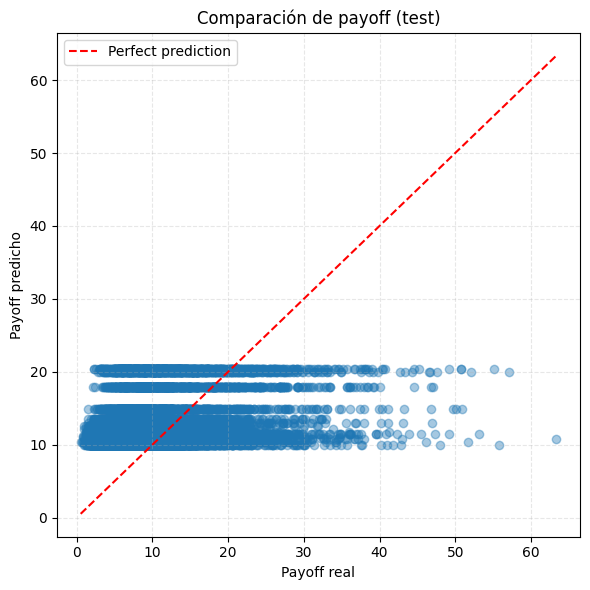

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(ytrue_te, yhat_te, alpha=0.4)
minv, maxv = min(ytrue_te.min(), yhat_te.min()), max(ytrue_te.max(), yhat_te.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', label="Perfect prediction")
plt.xlabel("Payoff real")
plt.ylabel("Payoff predicho")
plt.title("Comparación de payoff (test)")
plt.legend()
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

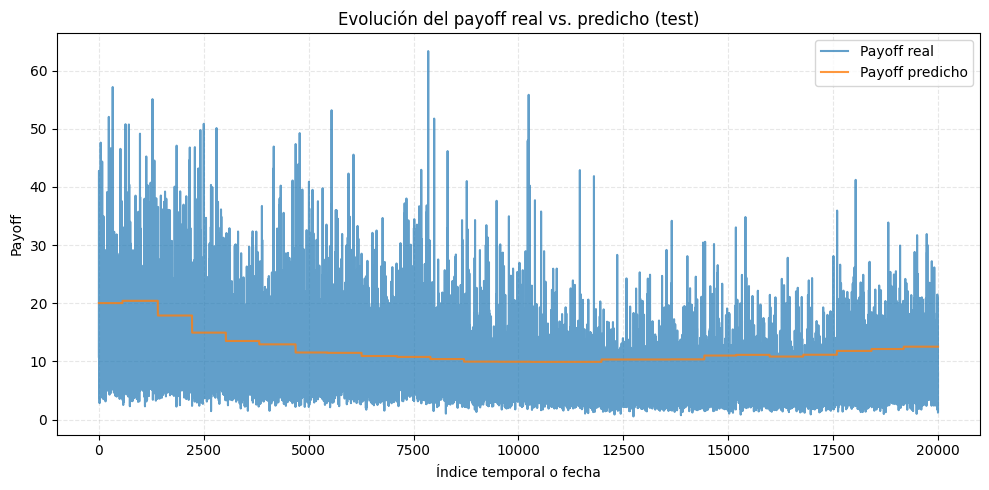

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Si tienes las fechas de test (ordenadas temporalmente)
# usa tu df_sorted o el DataFrame de test
# por ejemplo:
# fechas_test = df_sorted.iloc[idx_te]["trading_day_end"].values
# En caso contrario, usamos el índice 0..N_test-1
fechas_test = np.arange(len(ytrue_te))

plt.figure(figsize=(10,5))
plt.plot(fechas_test, ytrue_te, label="Payoff real", color="tab:blue", alpha=0.7)
plt.plot(fechas_test, yhat_te, label="Payoff predicho", color="tab:orange", alpha=0.8)
plt.xlabel("Índice temporal o fecha")
plt.ylabel("Payoff")
plt.title("Evolución del payoff real vs. predicho (test)")
plt.legend()
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


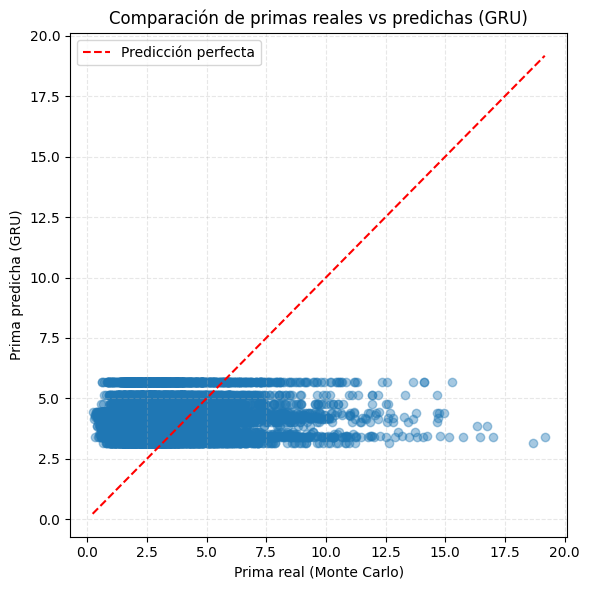


Ejemplo de 10 primas reales vs. predichas:
Real=2.7678  |  Predicha=5.1265
Real=6.1976  |  Predicha=5.1265
Real=3.1736  |  Predicha=5.1265
Real=10.9496  |  Predicha=5.1265
Real=1.5757  |  Predicha=5.1265
Real=0.9703  |  Predicha=5.1265
Real=3.8872  |  Predicha=5.1265
Real=2.0772  |  Predicha=5.1265
Real=5.1702  |  Predicha=5.1265
Real=1.6378  |  Predicha=5.1265


In [14]:
r_test = df_sorted.iloc[idx_te]["r_ann"].values
T_test = df_sorted.iloc[idx_te]["T_years"].values


prima_real = ytrue_te * np.exp(-r_test * T_test)
prima_pred = yhat_te * np.exp(-r_test * T_test)


plt.figure(figsize=(6,6))
plt.scatter(prima_real, prima_pred, alpha=0.4, color="tab:blue")
minv, maxv = min(prima_real.min(), prima_pred.min()), max(prima_real.max(), prima_pred.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', label="Predicción perfecta")
plt.xlabel("Prima real (Monte Carlo)")
plt.ylabel("Prima predicha (GRU)")
plt.title("Comparación de primas reales vs predichas (GRU)")
plt.legend()
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


print("\nEjemplo de 10 primas reales vs. predichas:")
for pr, pp in zip(prima_real[:10], prima_pred[:10]):
    print(f"Real={pr:.4f}  |  Predicha={pp:.4f}")

In [18]:
df_sorted.iloc[idx_te]

,trading_day_end,r_ann,sigma_AAPL,sigma_MSFT,sigma_CAT,corr_AM,corr_AC,corr_MC,S0_AAPL,S0_MSFT,...,AAPL_t17,MSFT_t17,CAT_t17,AAPL_t18,MSFT_t18,CAT_t18,AAPL_t19,MSFT_t19,CAT_t19,payoff
80000,2021-06-07,0.272378,0.233384,0.189308,0.234534,0.672922,-0.024674,-0.056524,125.890164,250.919145,...,0.981332,0.979240,0.999262,0.999999,0.999485,1.0,1.0,1.0,1.0,10.804178
80001,2021-06-07,0.272378,0.233384,0.189308,0.234534,0.672922,-0.024674,-0.056524,125.890164,250.919145,...,0.981332,0.979240,0.999262,0.999999,0.999485,1.0,1.0,1.0,1.0,24.192625
80002,2021-06-07,0.272378,0.233384,0.189308,0.234534,0.672922,-0.024674,-0.056524,125.890164,250.919145,...,0.981332,0.979240,0.999262,0.999999,0.999485,1.0,1.0,1.0,1.0,12.388515
80003,2021-06-07,0.272378,0.233384,0.189308,0.234534,0.672922,-0.024674,-0.056524,125.890164,250.919145,...,0.981332,0.979240,0.999262,0.999999,0.999485,1.0,1.0,1.0,1.0,42.742290
80004,2021-06-07,0.272378,0.233384,0.189308,0.234534,0.672922,-0.024674,-0.056524,125.890164,250.919145,...,0.981332,0.979240,0.999262,0.999999,0.999485,1.0,1.0,1.0,1.0,6.150973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2021-07-01,0.212321,0.217102,0.181057,0.239814,0.681445,-0.092400,-0.110610,136.330000,271.287613,...,0.988658,0.990508,1.005439,1.000000,1.000000,1.0,1.0,1.0,1.0,3.528718
99996,2021-07-01,0.212321,0.217102,0.181057,0.239814,0.681445,-0.092400,-0.110610,136.330000,271.287613,...,0.988658,0.990508,1.005439,1.000000,1.000000,1.0,1.0,1.0,1.0,9.429528
99997,2021-07-01,0.212321,0.217102,0.181057,0.239814,0.681445,-0.092400,-0.110610,136.330000,271.287613,...,0.988658,0.990508,1.005439,1.000000,1.000000,1.0,1.0,1.0,1.0,3.966985
99998,2021-07-01,0.212321,0.217102,0.181057,0.239814,0.681445,-0.092400,-0.110610,136.330000,271.287613,...,0.988658,0.990508,1.005439,1.000000,1.000000,1.0,1.0,1.0,1.0,1.176081
